# Convergencia y costo: estimador *next-event* vs. modo análogo

Análisis de las tres campañas gemelas `study_convergence_*` (homogéneo, mezcla,
bicapa). Las tres comparten escalera de fotones, número de réplicas, detector
único y protocolo de tiempos: **lo único que cambia es la arquitectura del
medio**, así que las diferencias que aparezcan son atribuibles al scoring y no
al montaje.

**Preguntas que responde el notebook**

1. ¿Convergen los dos modos al **mismo** $\eta(q)$? — test de sesgo.
2. ¿Cómo cae el ruido con $N$? — se espera $\sigma \propto N^{-1/2}$.
3. ¿Cuánto cuesta cada modo? — $T \propto N$, y el veredicto en
   $\mathrm{FOM} = 1/(\sigma^2 T)$, invariante en $N$ si las dos leyes se cumplen.
4. ¿Cómo se comparan los perfiles a **igual costo**, no a igual $N$?

**Organización**

1. Configuración y carga de las tres campañas.
2. Índice de corridas (se lee de `params_flat`, no del nombre del dataset).
3. Perfiles: estimador central *pooled* $\sum C/\sum I$ y banda por réplicas.
4. Figuras F1–F6 y tablas.

**Convenios estadísticos** (los mismos del resto de la tesis): el estimador
central de un cociente es el *pooled* $\sum C/\sum I$, nunca la media de
cocientes por réplica; las barras son $t_{0.975,R-1}\,s/\sqrt{R}$ con $R=5$
($t = 2.776$); las incertidumbres por bin de `curve_fit` no se usan.

## 1. Configuración

In [28]:
import sys
import os
sys.path.append(os.path.abspath("../"))

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, phi_cut, azimuthal_average

In [30]:
# --- rutas -----------------------------------------------------------------
save_path = "/Users/niaggar/Results"

FIGDIR = Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

# Nombres de carpeta de las tres campañas gemelas. AJUSTAR si difieren:
# el notebook salta sin quejarse las que no encuentre.
CAMPAIGNS = {
    "Homogeneous": "study_convergence_homogeneous_r55nm__CIRCULAR__beam2500",
    "Mixture":     "study_convergence_mixture__CIRCULAR__beam2500",
    "Bilayer":     "study_convergence_layers__CIRCULAR__beam2500",
}
MEDIA_ORDER = ["Homogeneous", "Mixture", "Bilayer"]

# --- física ----------------------------------------------------------------
N_MEDIUM   = 1.33
WAVELENGTH = 0.514                                   # um
K_MEDIUM   = 2 * np.pi * N_MEDIUM / WAVELENGTH       # 1/um

# Incidencia circular -> canal de helicidad conservada. En base circular
# "cross" = I_+ (el que va a eta(0) = 2 por reciprocidad).
BASIS   = circular
CHANNEL = "cross"
REDUCER = azimuthal_average       # obligatorio: el modo directo no admite
                                  # comparacion columna a columna en phi
SENSOR  = "farfield_cbs"          # detector unico (sin stitching)

# --- estadistica -----------------------------------------------------------
N_REPLICAS  = 5
T_CRIT      = 2.776               # t_{0.975,4}
Q_CONE      = 7.5                 # ventana del cono para las metricas de perfil
Q_TAIL_FRAC = 0.6                 # cola usada para la baseline incoherente
EPS         = 1e-30

# --- estilo ----------------------------------------------------------------
MODE_ORDER = ["estimator", "analog"]
MODE_STYLE = {
    "estimator": dict(color=COL[0], marker="o", ls="-"),
    "analog":    dict(color=COL[2], marker="s", ls="--"),
}
MEDIA_COLOR = {m: COL[i] for i, m in enumerate(MEDIA_ORDER)}
CMAP_N = plt.get_cmap("viridis")

## 2. Carga e índice de corridas

El índice se construye leyendo `params_flat` de cada dataset (`mode`,
`ladder_index`, `replica`, `n_photons`, `runtime_s`, ...), no parseando el
nombre: los pilotos de costo no se persisten, así que no contaminan nada.

In [31]:
sweeps = {}
for label, folder in CAMPAIGNS.items():
    try:
        sweeps[label] = load_sweep(folder, base_path=Path(save_path))
        print(f"{label:12s}: {len(sweeps[label]):3d} datasets   <- {folder}")
    except Exception as err:
        print(f"{label:12s}: NO DISPONIBLE ({type(err).__name__}: {err})")

MEDIA = [m for m in MEDIA_ORDER if m in sweeps]
print("\ncampanas activas:", MEDIA)

Homogeneous :  70 datasets   <- study_convergence_homogeneous_r55nm__CIRCULAR__beam2500
Mixture     :  70 datasets   <- study_convergence_mixture__CIRCULAR__beam2500
Bilayer     :  70 datasets   <- study_convergence_layers__CIRCULAR__beam2500

campanas activas: ['Homogeneous', 'Mixture', 'Bilayer']


In [32]:
def lstar_anchor(p):
    """l* con el que se construyo la grilla angular (q = k l* theta).

    Se prueban las claves en orden de especificidad; la primera que exista y
    sea > 0 gana. Si ninguna esta, la corrida no es interpretable en q."""
    for name in ("lstar_angle_anchor", "lstar_mix", "lstar_in",
                 "transport_mean_free_path", "lstar_sim"):
        v = p.get(name)
        if v is not None and np.isfinite(float(v)) and float(v) > 0:
            return float(v)
    raise KeyError("sin ancla de l* en params_flat")


def build_index(label, sweep):
    """Una fila por REPLICA."""
    rows = []
    for key in sweep.keys():
        p = sweep[key].params_flat
        mode = p.get("mode")
        if mode not in MODE_ORDER:          # corrida ajena a esta campana
            continue
        n_chunk = int(p.get("n_photons", 0))
        n_reps  = int(p.get("n_replicas", N_REPLICAS))
        rows.append(dict(
            medium  = label,
            key     = key,
            mode    = mode,
            idx     = int(p.get("ladder_index", -1)),
            rep     = int(p.get("replica", -1)),
            n_chunk = n_chunk,
            n_total = int(p.get("n_photons_point_total", n_chunk * n_reps)),
            wall_s  = float(p.get("runtime_s", np.nan)),
            cpu_s   = float(p.get("cpu_time_s", np.nan)),
            hits    = float(p.get("hits", np.nan)),
            lstar   = lstar_anchor(p),
        ))
    return pd.DataFrame(rows)


if not MEDIA:
    raise RuntimeError("ninguna campana encontrada: revisar save_path y CAMPAIGNS")

runs = pd.concat([build_index(m, sweeps[m]) for m in MEDIA], ignore_index=True)
runs = runs.sort_values(["medium", "mode", "n_total", "rep"]).reset_index(drop=True)

print(runs.groupby(["medium", "mode"])
          .agg(points=("n_total", "nunique"),
               runs=("key", "size"),
               N_min=("n_total", "min"),
               N_max=("n_total", "max"),
               wall_h=("wall_s", lambda s: s.sum() / 3600.0))
          .round(2))

                       points  runs    N_min       N_max  wall_h
medium      mode                                                
Bilayer     analog          7    35  1000000  1000000000    4.82
            estimator       7    35     1000      500000    0.75
Homogeneous analog          7    35  1000000  1000000000    1.45
            estimator       7    35     1000      500000    0.23
Mixture     analog          7    35  1000000  1000000000    1.52
            estimator       7    35     1000      500000    2.65


## 3. Perfiles y escalares

Pipeline por punto de la escalera:

1. Se leen las $R$ réplicas del **mismo** punto (mismo modo, mismo $N$).
2. Central: $\eta = \sum_r C_r / \sum_r I_r$ (las réplicas son trozos
   independientes de $N/R$ con idéntica normalización, así que la suma recupera
   la estadística de $N$).
3. Banda: $t\,s/\sqrt{R}$ sobre los $\eta$ **por réplica**.
4. La cola se lleva a 1 restando la mediana del fondo incoherente
   ($q > 0.6\,q_{\max}$; con $q_{\max}=40$ sobra cola fuera del cono).

In [33]:
def raw_pair(sweep, key, lstar, time_index=0):
    """(q, coherente, incoherente) de UNA replica, sin normalizar."""
    p = cbs_profiles(sweep[key].processed_cbs(SENSOR),
                     basis=BASIS, time_index=time_index, reduce=REDUCER)
    q = K_MEDIUM * lstar * np.asarray(p.theta, float)
    return (q,
            np.asarray(p.coherent[CHANNEL],   float),
            np.asarray(p.incoherent[CHANNEL], float))


def tail_baseline(q, y, frac=Q_TAIL_FRAC):
    """Fondo incoherente = mediana de la cola. Robusto a pedestales residuales."""
    m = q > frac * q[-1]
    if m.sum() < 5:
        raise ValueError("cola insuficiente para estimar el fondo")
    return np.median(y[m])


def peak_height(q, E, n=3):
    """Apice como mediana de los primeros n bins (inmune a un bin ruidoso)."""
    return float(np.median(E[:n]))


def fwhm_q(q, E, n=3, sustain=2):
    """FWHM en q respecto al fondo incoherente.

    sustain: bins consecutivos bajo el semi-maximo exigidos para aceptar el
    cruce (a N bajo el ruido cruza y vuelve). Devuelve nan si no hay cono."""
    B  = tail_baseline(q, E)
    E0 = peak_height(q, E, n)
    if E0 <= B:
        return np.nan
    half  = B + 0.5 * (E0 - B)
    below = E < half
    for i in range(1, len(E) - sustain + 1):
        if below[i:i + sustain].all():
            break
    else:
        return np.nan
    if below[:i].all():
        return np.nan
    j = i - 1
    while j > 0 and E[j] < half:
        j -= 1
    q_half = q[j] + (half - E[j]) * (q[j + 1] - q[j]) / (E[j + 1] - E[j])
    return 2.0 * q_half


def mirror(q, *ys):
    """Espejo -q..+q (valido: I(th,phi) = I(th,phi+pi))."""
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)

In [34]:
def eta_point(sweep, keys, lstar, time_index=0):
    """Perfil de UN punto de la escalera.

    Devuelve (q, eta_pooled, semiancho_IC, eta_por_replica)."""
    C = I = q = None
    per_rep = []
    for k in keys:
        q, c, i = raw_pair(sweep, k, lstar, time_index)
        C = c if C is None else C + c
        I = i if I is None else I + i
        e = (c + EPS) / (i + EPS)
        per_rep.append(e - tail_baseline(q, e) + 1.0)

    eta = (C + EPS) / (I + EPS)
    eta = eta - tail_baseline(q, eta) + 1.0

    per_rep = np.vstack(per_rep)
    R = per_rep.shape[0]
    half = T_CRIT * per_rep.std(axis=0, ddof=1) / np.sqrt(R)
    return q, eta, half, per_rep


def build_points(medium):
    """{(modo, N_total): dict con perfil, escalares y costo}."""
    sweep = sweeps[medium]
    sub   = runs[runs.medium == medium]
    out   = {}
    for (mode, n_total), grp in sub.groupby(["mode", "n_total"]):
        grp   = grp.sort_values("rep")
        lstar = float(grp.lstar.iloc[0])
        q, eta, half, per_rep = eta_point(sweep, grp.key.tolist(), lstar)
        R = per_rep.shape[0]

        e0_rep = np.array([peak_height(q, e) for e in per_rep])
        dq_rep = np.array([fwhm_q(q, e)      for e in per_rep])

        out[(mode, int(n_total))] = dict(
            q=q, eta=eta, half=half, per_rep=per_rep, R=R, lstar=lstar,
            eta0   = peak_height(q, eta),
            dq     = fwhm_q(q, eta),
            # sigma del punto COMPLETO = s_replica / sqrt(R)
            s_eta0 = np.nanstd(e0_rep, ddof=1) / np.sqrt(R),
            s_dq   = np.nanstd(dq_rep, ddof=1) / np.sqrt(R),
            T_wall = float(grp.wall_s.sum()),
            T_cpu  = float(grp.cpu_s.sum()),
            hits   = float(grp.hits.sum()),
        )
    return out


POINTS = {m: build_points(m) for m in MEDIA}
LADDER = {(m, mode): sorted(n for (md_, n) in POINTS[m] if md_ == mode)
          for m in MEDIA for mode in MODE_ORDER}
NMAX   = {(m, mode): LADDER[(m, mode)][-1] for m in MEDIA for mode in MODE_ORDER
          if LADDER[(m, mode)]}

for m in MEDIA:
    for mode in MODE_ORDER:
        print(f"{m:12s} {mode:9s}: N = {[f'{n:.0e}' for n in LADDER[(m, mode)]]}")

/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Homogeneous  estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Homogeneous  analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Mixture      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Mixture      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Bilayer      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Bilayer      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']


/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [35]:
# --- chequeo: la grilla en q debe ser IDENTICA en toda la campana -----------
for m in MEDIA:
    qs = [d["q"] for d in POINTS[m].values()]
    same = all(np.allclose(qs[0], x) for x in qs)
    print(f"{m:12s}: grilla q identica = {same} | dq = {np.diff(qs[0]).mean():.4f} "
          f"| q_max = {qs[0][-1]:.1f} | l*_ancla = "
          f"{ {round(d['lstar'], 4) for d in POINTS[m].values()} }")

Homogeneous : grilla q identica = True | dq = 0.0200 | q_max = 40.0 | l*_ancla = {39.7958}
Mixture     : grilla q identica = True | dq = 0.0200 | q_max = 40.0 | l*_ancla = {20.4125}
Bilayer     : grilla q identica = True | dq = 0.0200 | q_max = 40.0 | l*_ancla = {23.2166}


## 4. F1 — ¿Convergen al mismo límite?

Fila superior: los dos modos a su $N_{\max}$ respectivo, con banda $\pm$IC.
Fila inferior: el residuo $\Delta\eta = \eta_{\rm est} - \eta_{\rm ana}$ con la
banda combinada $\sqrt{h_{\rm est}^2 + h_{\rm ana}^2}$. **Compatible con cero
dentro de la banda = no hay sesgo de scoring.** Es el único test que importa
antes de mirar costos.

In [36]:
def banda(ax, q, m, s, color, **kw):
    """Curva media con banda +-IC, espejada."""
    qs, ms, ss = mirror(q, m, s)
    ax.plot(qs, ms, color=color, **kw)
    ax.fill_between(qs, ms - ss, ms + ss, color=color, alpha=0.20, lw=0)


def leyenda_inferior(fig, ax, ncol=4):
    fig.legend(*ax.get_legend_handles_labels(), ncol=ncol,
               loc="outside lower center", frameon=False,
               columnspacing=1.4, handlelength=1.4)

In [37]:
# =========================================================================
# T -- transformacion (ancho, amplitud) entre modos + perfil corregido
#      Requiere rebin_pair() de la celda E.
# =========================================================================
from scipy.optimize import curve_fit

DQ_T    = 0.10      # resolucion de trabajo
Q_FIT_T = 6.0       # ventana de ajuste (el cono, sin la cola)


def rebinned(medium, mode, dq_new, n=None):
    """(q, eta_pooled, eta_por_replica, semiancho_IC) a resolucion dq_new."""
    sweep = sweeps[medium]
    n = n if n is not None else NMAX[(medium, mode)]
    grp = runs[(runs["medium"] == medium) & (runs["mode"] == mode)
               & (runs["n_total"] == n)].sort_values("rep")
    lstar = float(grp["lstar"].iloc[0])

    Cs, Is, qb = [], [], None
    for k in grp["key"]:
        q, c, i = raw_pair(sweep, k, lstar)
        qb, cb, ib = rebin_pair(q, c, i, dq_new)
        Cs.append(cb); Is.append(ib)
    Cs, Is = np.vstack(Cs), np.vstack(Is)

    ok   = (Is > 0).all(axis=0) & (Cs > 0).all(axis=0)
    qb   = qb[ok]
    tail = qb > 0.6 * qb[-1]

    per_rep = Cs[:, ok] / Is[:, ok]
    per_rep = per_rep - np.median(per_rep[:, tail], axis=1, keepdims=True) + 1.0
    eta = Cs[:, ok].sum(axis=0) / Is[:, ok].sum(axis=0)
    eta = eta - np.median(eta[tail]) + 1.0
    half = T_CRIT * per_rep.std(axis=0, ddof=1) / np.sqrt(per_rep.shape[0])
    return qb, eta, per_rep, half


def _model(qq, s, A, q_ref, e_ref):
    """1 + A*[eta_est(q/s) - 1], por interpolacion sobre la referencia."""
    return 1.0 + A * np.interp(qq / s, q_ref, e_ref - 1.0,
                               left=e_ref[0] - 1.0, right=0.0)


def fit_sA(q, y, q_ref, e_ref, q_fit=Q_FIT_T):
    m = (q > 0) & (q < q_fit) & np.isfinite(y)
    popt, _ = curve_fit(lambda qq, s, A: _model(qq, s, A, q_ref, e_ref),
                        q[m], y[m], p0=[1.0, 1.0],
                        bounds=([0.5, 0.5], [2.0, 1.5]), maxfev=20000)
    return popt


def apply_transform(q, eta, s, A):
    """Lleva el analog al marco del estimador."""
    return 1.0 + np.interp(s * q, q, eta - 1.0,
                           left=eta[0] - 1.0, right=0.0) / A


TRANS, rows = {}, []
for m in MEDIA:
    q_ref, e_ref, _,     h_ref = rebinned(m, "estimator", DQ_T)
    q_a,   e_a,  rep_a,  h_a   = rebinned(m, "analog",    DQ_T)

    v = np.array([fit_sA(q_a, r, q_ref, e_ref) for r in rep_a])   # (R, 2)
    (s_hat, A_hat) = v.mean(axis=0)
    ci = T_CRIT * v.std(axis=0, ddof=1) / np.sqrt(v.shape[0])
    TRANS[m] = dict(s=s_hat, A=A_hat, ci_s=ci[0], ci_A=ci[1],
                    q_ref=q_ref, e_ref=e_ref, h_ref=h_ref,
                    q_a=q_a, e_a=e_a, h_a=h_a)

    e_corr = apply_transform(q_a, e_a, s_hat, A_hat)
    sel    = q_a < Q_FIT_T
    rows.append({
        "medium":            m,
        "s (ancho ana/est)": s_hat,     "CI_s": ci[0],
        "A (amp ana/est)":   A_hat,     "CI_A": ci[1],
        "lstar_ana/lstar_est": 1.0 / s_hat,
        "rms antes":  np.sqrt(np.mean((e_a[sel]     - np.interp(q_a[sel], q_ref, e_ref)) ** 2)),
        "rms despues": np.sqrt(np.mean((e_corr[sel] - np.interp(q_a[sel], q_ref, e_ref)) ** 2)),
    })

df_T = pd.DataFrame(rows)
df_T.to_csv(FIGDIR / "conv_mode_transform.csv", index=False)
print(df_T.round(4).to_string(index=False))

     medium  s (ancho ana/est)   CI_s  A (amp ana/est)   CI_A  lstar_ana/lstar_est  rms antes  rms despues
Homogeneous             0.5749 0.0566           1.0912 0.0790               1.7394     0.0784       0.0175
    Mixture             0.9054 0.0244           0.9624 0.0373               1.1045     0.0262       0.0081
    Bilayer             0.7513 0.2015           1.0582 0.1654               1.3310     0.0367       0.0204


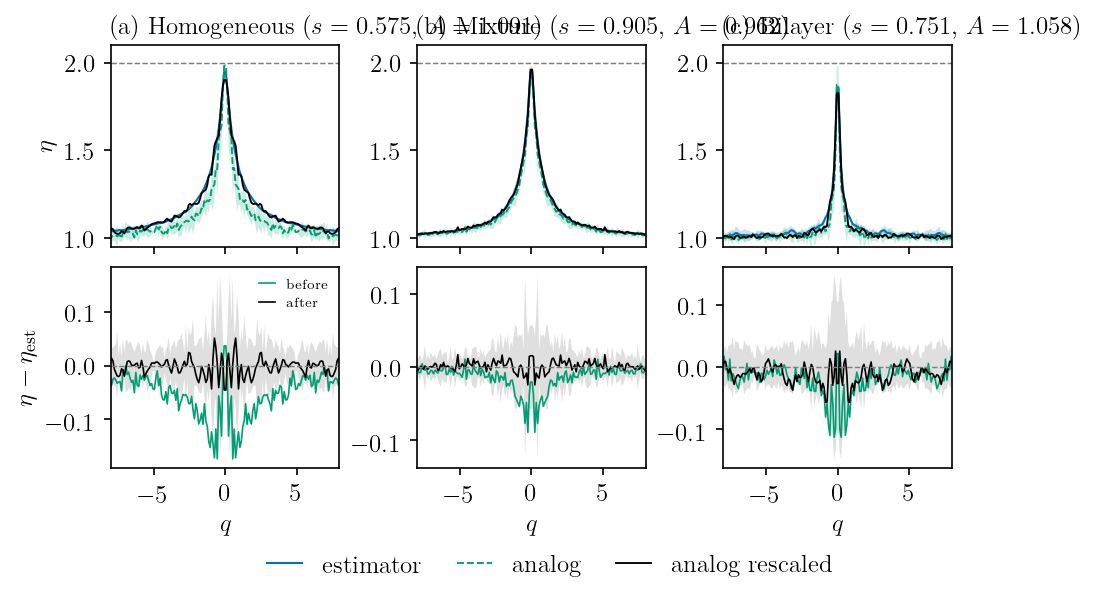

In [38]:
apply(width_frac=1.0)
fig, axes = plt.subplots(2, len(MEDIA), figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                         sharex=True, squeeze=False)
tags = iter("abcdef")

for j, m in enumerate(MEDIA):
    t = TRANS[m]
    top, bot = axes[0, j], axes[1, j]
    e_corr = apply_transform(t["q_a"], t["e_a"], t["s"], t["A"])
    ref_on_a = np.interp(t["q_a"], t["q_ref"], t["e_ref"])

    banda(top, t["q_ref"], t["e_ref"], t["h_ref"], color=MODE_STYLE["estimator"]["color"],
          lw=1.0, label="estimator")
    banda(top, t["q_a"], t["e_a"], t["h_a"], color=MODE_STYLE["analog"]["color"],
          ls="--", lw=0.9, label="analog")
    qs, cs = mirror(t["q_a"], e_corr)
    top.plot(qs, cs, "k-", lw=0.9, label="analog rescaled")

    for y, c, lb in ((t["e_a"] - ref_on_a, MODE_STYLE["analog"]["color"], "before"),
                     (e_corr   - ref_on_a, "k", "after")):
        qs, ys = mirror(t["q_a"], y)
        bot.plot(qs, ys, color=c, lw=0.8, label=lb)
    qs, hs = mirror(t["q_a"], np.hypot(t["h_a"], np.interp(t["q_a"], t["q_ref"], t["h_ref"])))
    bot.fill_between(qs, -hs, hs, color="gray", alpha=0.25, lw=0)
    bot.axhline(0.0, ls="--", c="gray", lw=0.7)

    top.set_title(rf"({next(tags)}) {m}  ($s={t['s']:.3f}$, $A={t['A']:.3f}$)", loc="left")
    top.axhline(2.0, ls="--", c="gray", lw=0.7)
    top.set_xlim(-8, 8); top.set_ylim(0.95, 2.10)
    bot.set_xlabel(r"$q$")
    for ax in (top, bot):
        ax.grid(False)

axes[0, 0].set_ylabel(r"$\eta$")
axes[1, 0].set_ylabel(r"$\eta - \eta_{\mathrm{est}}$")
axes[1, 0].legend(frameon=False, fontsize=6.5, handlelength=1.2, loc="upper right")
leyenda_inferior(fig, axes[0, 0], ncol=3)
fig.savefig(FIGDIR / "conv_mode_transform.pdf")
plt.show()

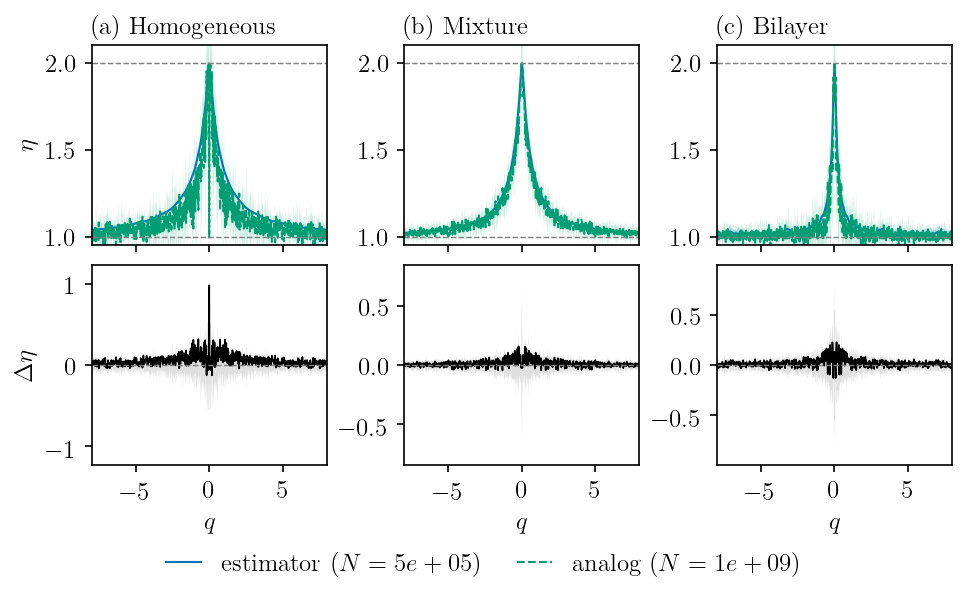

,medium,max_abs_delta,rms_delta,max_z,frac_outside
0,Homogeneous,0.9893,0.0985,256.3549,0.1920
1,Mixture,0.1611,0.0322,5.5572,0.0533
2,Bilayer,0.2301,0.0459,1.9883,0.0427


In [39]:
apply(width_frac=1.0)
fig, axes = plt.subplots(2, len(MEDIA), figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                         sharex=True, squeeze=False)
tags = iter("abcdef")

resid_rows = []
for j, m in enumerate(MEDIA):
    top, bot = axes[0, j], axes[1, j]
    d = {mode: POINTS[m][(mode, NMAX[(m, mode)])] for mode in MODE_ORDER}

    for mode in MODE_ORDER:
        st = MODE_STYLE[mode]
        banda(top, d[mode]["q"], d[mode]["eta"], d[mode]["half"],
              color=st["color"], ls=st["ls"], lw=1.0,
              label=f"{mode} ($N={NMAX[(m, mode)]:.0e}$)")

    q      = d["estimator"]["q"]
    delta  = d["estimator"]["eta"] - d["analog"]["eta"]
    hcomb  = np.hypot(d["estimator"]["half"], d["analog"]["half"])
    qs, ds, hs = mirror(q, delta, hcomb)
    bot.plot(qs, ds, color="k", lw=0.8)
    bot.fill_between(qs, -hs, hs, color="gray", alpha=0.25, lw=0)
    bot.axhline(0.0, ls="--", c="gray", lw=0.7)
    core_m = q < Q_CONE
    mx = 1.25 * max(np.max(np.abs(delta[core_m])), np.max(hcomb[core_m]))
    bot.set_ylim(-mx, mx)

    top.set_title(rf"({next(tags)}) {m}", loc="left")
    top.axhline(1.0, ls="--", c="gray", lw=0.7)
    top.axhline(2.0, ls="--", c="gray", lw=0.7)
    top.set_xlim(-8, 8)
    top.set_ylim(0.95, 2.10)
    bot.set_xlabel(r"$q$")
    for ax in (top, bot):
        ax.grid(False)

    # significancia del residuo dentro del cono
    core = (q < Q_CONE)
    z    = np.abs(delta[core]) / np.where(hcomb[core] > 0, hcomb[core], np.nan)
    resid_rows.append(dict(medium=m,
                           max_abs_delta=np.max(np.abs(delta[core])),
                           rms_delta=np.sqrt(np.mean(delta[core] ** 2)),
                           max_z=np.nanmax(z),
                           frac_outside=np.nanmean(z > 1.0)))

axes[0, 0].set_ylabel(r"$\eta$")
axes[1, 0].set_ylabel(r"$\Delta\eta$")
leyenda_inferior(fig, axes[0, 0], ncol=2)
fig.savefig(FIGDIR / "conv_estimator_vs_analog.pdf")
plt.show()

df_resid = pd.DataFrame(resid_rows)
df_resid.to_csv(FIGDIR / "conv_bias_test.csv", index=False)
df_resid.round(4)

D1 -- las dos filas de cada campana deben ser IDENTICAS
     medium      mode  n_theta  q_max  theta_max  d_theta  n_phi_nominal  lstar_angle_anchor  transport_mean_free_path  radius  n_threads
Homogeneous estimator     2000   40.0   0.061824 0.000031            NaN           39.795837                 39.795837   0.055         46
Homogeneous    analog     2000   40.0   0.061824 0.000031            NaN           39.795837                 39.795837   0.055         46
    Mixture estimator     2000   40.0   0.120530 0.000060            1.0           20.412471                 20.412471     NaN         46
    Mixture    analog     2000   40.0   0.120530 0.000060            1.0           20.412471                 20.412471     NaN         46
    Bilayer estimator     2000   40.0   0.105973 0.000053            NaN           23.216580                       NaN   0.035         46
    Bilayer    analog     2000   40.0   0.105973 0.000053            NaN           23.216580                       N

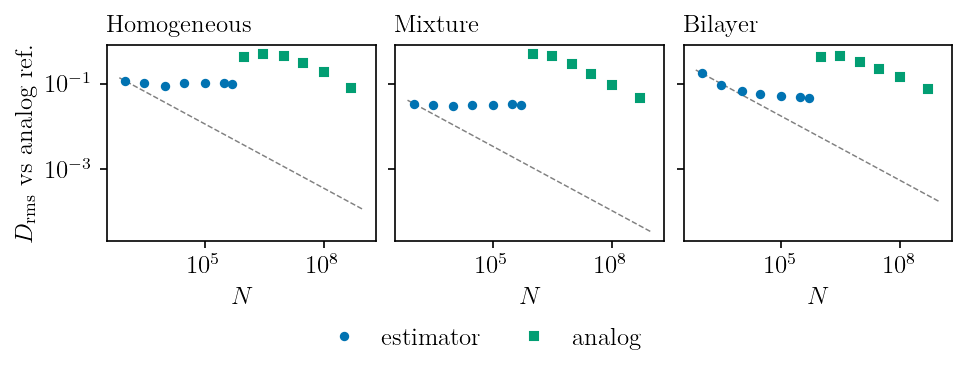


D4 -- cobertura excluyendo los primeros bins (nominal: 0.05)
     medium  skip_bins  q_min  rms_delta  frac_outside
Homogeneous          0 0.0000     0.0985        0.1920
Homogeneous          1 0.0200     0.0844        0.1898
Homogeneous          3 0.0600     0.0846        0.1909
Homogeneous         10 0.2001     0.0848        0.1890
    Mixture          0 0.0000     0.0322        0.0533
    Mixture          1 0.0200     0.0323        0.0535
    Mixture          3 0.0600     0.0323        0.0511
    Mixture         10 0.2001     0.0320        0.0521
    Bilayer          0 0.0000     0.0459        0.0427
    Bilayer          1 0.0200     0.0460        0.0428
    Bilayer          3 0.0600     0.0456        0.0430
    Bilayer         10 0.2001     0.0429        0.0411


In [40]:
# =========================================================================
# D -- triage del residuo de F1
# =========================================================================
def raw_point(medium, mode, n=None):
    """Perfil POOLED SIN corregir baseline, + los acumuladores crudos."""
    sweep = sweeps[medium]
    n = n if n is not None else NMAX[(medium, mode)]
    grp = runs[(runs["medium"] == medium) & (runs["mode"] == mode)
               & (runs["n_total"] == n)].sort_values("rep")
    lstar = float(grp["lstar"].iloc[0])
    C = I = q = None
    for k in grp["key"]:
        q, c, i = raw_pair(sweep, k, lstar)
        C = c if C is None else C + c
        I = i if I is None else I + i
    return q, (C + EPS) / (I + EPS), C, I


# --- D1: la grilla, modo a modo dentro de cada campana -------------------
META = ("n_theta", "q_max", "theta_max", "d_theta", "n_phi_nominal",
        "lstar_angle_anchor", "transport_mean_free_path", "radius", "n_threads")
rows = []
for m in MEDIA:
    for mode in MODE_ORDER:
        k = runs[(runs["medium"] == m) & (runs["mode"] == mode)]["key"].iloc[0]
        p = sweeps[m][k].params_flat
        rows.append({"medium": m, "mode": mode, **{x: p.get(x) for x in META}})
print("D1 -- las dos filas de cada campana deben ser IDENTICAS")
print(pd.DataFrame(rows).to_string(index=False))


# --- D2: el apice en unidades crudas -------------------------------------
# Cota dura: eta <= 2 por reciprocidad.  I[0]/I_cola debe ser ~1 (el
# incoherente por angulo solido es plano; si no, el primer bin esta mal
# normalizado y el problema es geometrico, no de scoring).
rows = []
for m in MEDIA:
    for mode in MODE_ORDER:
        q, eta, C, I = raw_point(m, mode)
        tail = q > 0.6 * q[-1]
        rows.append({"medium": m, "mode": mode,
                     "eta[0]": eta[0], "eta[1]": eta[1], "eta[2]": eta[2],
                     "eta[5]": eta[5], "baseline": np.median(eta[tail]),
                     "I[0]/I_tail": I[0] / np.median(I[tail])})
print("\nD2 -- apice crudo (sin baseline)")
print(pd.DataFrame(rows).round(4).to_string(index=False))


# --- D3: sesgo o falta de estadistica? -----------------------------------
# RMS del estimador a cada N contra la referencia ANALOG a N_max.
# Cae como N^-1/2 -> el residuo de F1 es ruido del estimador a 5e5.
# Se aplana        -> hay sesgo, y la meseta lo mide.
apply(width_frac=1.0)
fig, axes = plt.subplots(1, len(MEDIA), figsize=(TEXTWIDTH_IN, 0.38 * TEXTWIDTH_IN),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, m in zip(axes, MEDIA):
    q   = POINTS[m][("analog", NMAX[(m, "analog")])]["q"]
    ref = POINTS[m][("analog", NMAX[(m, "analog")])]["eta"]
    for mode in MODE_ORDER:
        ns = LADDER[(m, mode)][:-1] if mode == "analog" else LADDER[(m, mode)]
        D  = [rms_dev(q, POINTS[m][(mode, n)]["eta"], ref) for n in ns]
        st = MODE_STYLE[mode]
        ax.plot(ns, D, marker=st["marker"], ms=3.5, ls="none",
                color=st["color"], label=mode)
    ns0 = LADDER[(m, "estimator")]
    D0  = rms_dev(q, POINTS[m][("estimator", ns0[0])]["eta"], ref)
    nl  = np.array([ns0[0] * 0.7, LADDER[(m, "analog")][-1]])
    ax.plot(nl, D0 * (nl / ns0[0]) ** -0.5, "--", c="gray", lw=0.7, zorder=0)
    ax.set(xscale="log", yscale="log", xlabel=r"$N$")
    ax.set_title(m, loc="left")
    ax.grid(False)
axes[0].set_ylabel(r"$D_{\mathrm{rms}}$ vs analog ref.")
leyenda_inferior(fig, axes[0], ncol=2)
fig.savefig(FIGDIR / "conv_cross_mode_rms.pdf")
plt.show()


# --- D4: la tabla de F1 excluyendo el nucleo del apice --------------------
rows = []
for m in MEDIA:
    de = POINTS[m][("estimator", NMAX[(m, "estimator")])]
    da = POINTS[m][("analog",    NMAX[(m, "analog")])]
    q, delta = de["q"], de["eta"] - da["eta"]
    hcomb = np.hypot(de["half"], da["half"])
    for skip in (0, 1, 3, 10):
        sel = (q < Q_CONE) & (np.arange(q.size) >= skip)
        z = np.abs(delta[sel]) / np.where(hcomb[sel] > 0, hcomb[sel], np.nan)
        rows.append({"medium": m, "skip_bins": skip, "q_min": q[skip],
                     "rms_delta": np.sqrt(np.mean(delta[sel] ** 2)),
                     "frac_outside": np.nanmean(z > 1.0)})
print("\nD4 -- cobertura excluyendo los primeros bins (nominal: 0.05)")
print(pd.DataFrame(rows).round(4).to_string(index=False))

In [41]:
# =========================================================================
# E -- comparacion a resolucion comun (rebin con peso de angulo solido)
# =========================================================================
def rebin_pair(q, C, I, dq_new):
    """Re-binea los ACUMULADORES (nunca el cociente) a una grilla mas gruesa.

    C e I ya vienen normalizados por angulo solido, asi que el promedio
    correcto pesa por dOmega ~ sin(theta) dtheta dphi ~ q. El q de salida es
    el CENTROIDE pesado por dOmega, que es el angulo al que el modo directo
    realmente reporta -- no el centro geometrico. Para el primer bin la
    diferencia es 4/3."""
    edges = np.arange(0.0, q[-1] + dq_new, dq_new)
    idx   = np.clip(np.digitize(q, edges) - 1, 0, len(edges) - 2)
    w     = np.maximum(q, 1e-12)                      # dOmega
    n     = len(edges) - 1
    W     = np.bincount(idx, weights=w, minlength=n)
    good  = W > 0
    agg   = lambda y: np.bincount(idx, weights=y * w, minlength=n)[good] / W[good]
    return agg(q), agg(C), agg(I)


def eta_point_rebin(medium, mode, dq_new, n=None):
    """Como eta_point pero a resolucion dq_new, con mascara de bins vacios."""
    sweep = sweeps[medium]
    n = n if n is not None else NMAX[(medium, mode)]
    grp = runs[(runs["medium"] == medium) & (runs["mode"] == mode)
               & (runs["n_total"] == n)].sort_values("rep")
    lstar = float(grp["lstar"].iloc[0])

    Cs, Is, qb = [], [], None
    for k in grp["key"]:
        q, c, i = raw_pair(sweep, k, lstar)
        qb, cb, ib = rebin_pair(q, c, i, dq_new)
        Cs.append(cb); Is.append(ib)
    Cs, Is = np.vstack(Cs), np.vstack(Is)

    # Un bin es utilizable si TODAS las replicas tienen senal ahi. Sin esto,
    # EPS convierte un bin vacio en eta = 1 exacto: el pico espureo de F1.
    ok = (Is > 0).all(axis=0) & (Cs > 0).all(axis=0)
    qb, per_rep = qb[ok], Cs[:, ok] / Is[:, ok]

    eta  = Cs[:, ok].sum(axis=0) / Is[:, ok].sum(axis=0)          # pooled
    tail = qb > 0.6 * qb[-1]
    eta  = eta - np.median(eta[tail]) + 1.0
    per_rep = per_rep - np.median(per_rep[:, tail], axis=1, keepdims=True) + 1.0
    half = T_CRIT * per_rep.std(axis=0, ddof=1) / np.sqrt(per_rep.shape[0])
    return qb, eta, half, int(ok.sum()), int((~ok).sum())


DQ_NEW = 0.20        # 10x mas grueso -> el ruido del analog baja ~3.2x

rows = []
for m in MEDIA:
    d = {}
    for mode in MODE_ORDER:
        q, eta, half, n_ok, n_bad = eta_point_rebin(m, mode, DQ_NEW)
        d[mode] = (q, eta, half)
        print(f"{m:12s} {mode:9s}: {n_ok} bins utiles, {n_bad} descartados")
    q     = d["estimator"][0]
    delta = d["estimator"][1] - d["analog"][1]
    hcomb = np.hypot(d["estimator"][2], d["analog"][2])
    sel   = q < Q_CONE
    z     = np.abs(delta[sel]) / np.where(hcomb[sel] > 0, hcomb[sel], np.nan)
    rows.append({"medium": m, "dq": DQ_NEW,
                 "rms_delta": np.sqrt(np.mean(delta[sel] ** 2)),
                 "max_z": np.nanmax(z), "frac_outside": np.nanmean(z > 1.0)})

print()
print(pd.DataFrame(rows).round(4).to_string(index=False))
# ojo: eta(0) y dq_FWHM NO se leen del bin crudo a esta resolucion.
# Pasar (q, eta, half) por el ajuste de cono de utils.cbs_fit y comparar
# ell_star y A con sus IC: esa es la comparacion que se cita.

Homogeneous  estimator: 200 bins utiles, 0 descartados
Homogeneous  analog   : 200 bins utiles, 0 descartados
Mixture      estimator: 200 bins utiles, 0 descartados
Mixture      analog   : 200 bins utiles, 0 descartados
Bilayer      estimator: 200 bins utiles, 0 descartados
Bilayer      analog   : 200 bins utiles, 0 descartados

     medium  dq  rms_delta  max_z  frac_outside
Homogeneous 0.2     0.0696 5.3629        0.7368
    Mixture 0.2     0.0226 3.9958        0.2632
    Bilayer 0.2     0.0325 2.1373        0.1842


## 5. F2 — Convergencia del perfil con $N$

Cada fila es un modo; el color codifica $N$. La curva negra es la referencia del
propio modo ($N_{\max}$). Se lee de un vistazo dónde la escalera ya está
convergida y dónde el ruido todavía domina las alas.

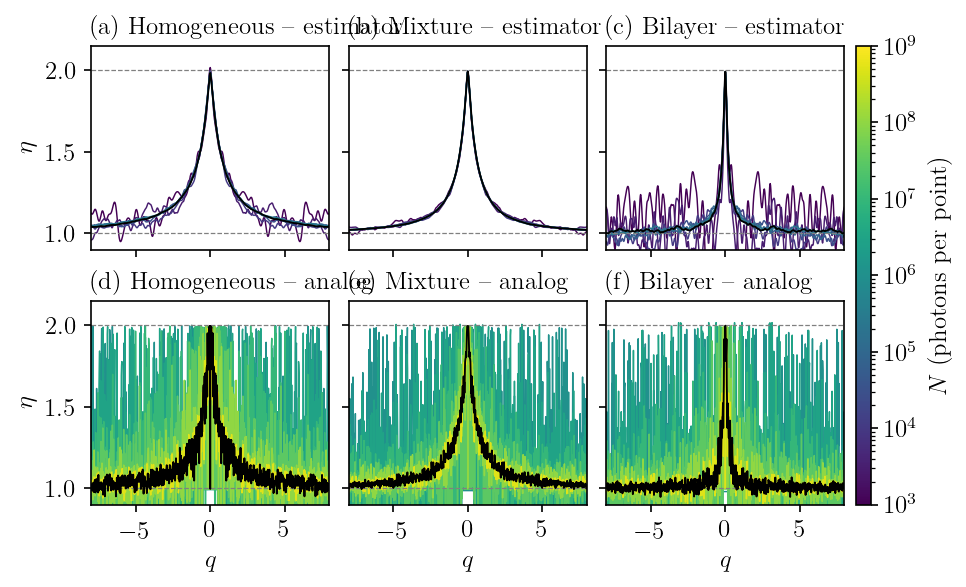

In [42]:
apply(width_frac=1.0)
fig, axes = plt.subplots(len(MODE_ORDER), len(MEDIA),
                         figsize=(TEXTWIDTH_IN, 0.60 * TEXTWIDTH_IN),
                         sharex=True, sharey=True, squeeze=False)

all_N = [n for k in LADDER for n in LADDER[k]]
norm  = LogNorm(vmin=min(all_N), vmax=max(all_N))
tags  = iter("abcdef")

for i, mode in enumerate(MODE_ORDER):
    for j, m in enumerate(MEDIA):
        ax = axes[i, j]
        for n in LADDER[(m, mode)]:
            d = POINTS[m][(mode, n)]
            qs, es = mirror(d["q"], d["eta"])
            ax.plot(qs, es, color=CMAP_N(norm(n)), lw=0.7)
        ref = POINTS[m][(mode, NMAX[(m, mode)])]
        qs, es = mirror(ref["q"], ref["eta"])
        ax.plot(qs, es, color="k", lw=0.9, zorder=5)

        ax.axhline(1.0, ls="--", c="gray", lw=0.6)
        ax.axhline(2.0, ls="--", c="gray", lw=0.6)
        ax.set_title(rf"({next(tags)}) {m} -- {mode}", loc="left")
        ax.set_xlim(-8, 8)
        ax.set_ylim(0.90, 2.15)
        ax.grid(False)

for ax in axes[-1]:   ax.set_xlabel(r"$q$")
for ax in axes[:, 0]: ax.set_ylabel(r"$\eta$")

sm = ScalarMappable(norm=norm, cmap=CMAP_N)
cb = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.015, aspect=30)
cb.set_label(r"$N$ (photons per point)")
fig.savefig(FIGDIR / "conv_profile_ladder.pdf")
plt.show()

## 6. F3 — Convergencia cuantitativa del perfil

$D_{\rm rms}(N) = \big\langle (\eta_N - \eta_{\rm ref})^2 \big\rangle^{1/2}$
sobre $q < 7.5$, con $\eta_{\rm ref}$ la referencia del **propio** modo (el
último punto queda excluido: es cero por construcción). La guía gris es
$N^{-1/2}$ anclada al primer punto.

La línea punteada horizontal es el **piso sistemático**: el $D_{\rm rms}$ entre
las dos referencias. Si las dos series bajan por debajo de ese piso, lo que
queda no es ruido sino diferencia entre modos.

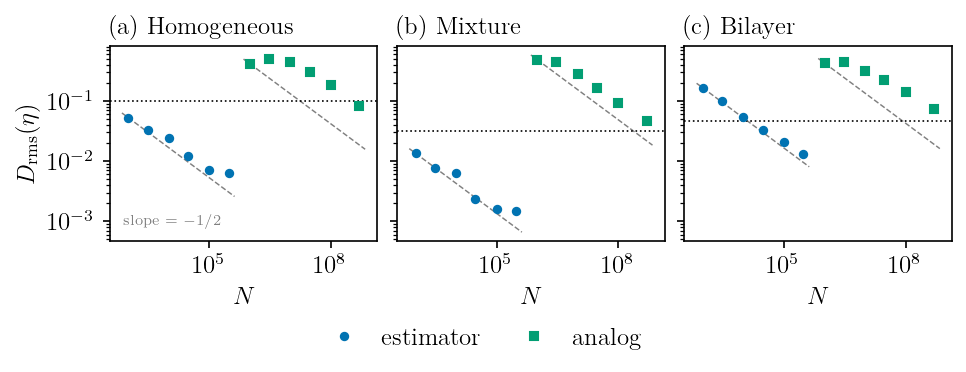

,medium,mode,slope
0,Homogeneous,estimator,-0.396
1,Homogeneous,analog,-0.276
2,Mixture,estimator,-0.416
3,Mixture,analog,-0.397
4,Bilayer,estimator,-0.444
5,Bilayer,analog,-0.294


In [43]:
def rms_dev(q, a, b, q_cut=Q_CONE):
    core = q < q_cut
    return float(np.sqrt(np.mean((a[core] - b[core]) ** 2)))


apply(width_frac=1.0)
fig, axes = plt.subplots(1, len(MEDIA), figsize=(TEXTWIDTH_IN, 0.38 * TEXTWIDTH_IN),
                         sharey=True, squeeze=False)
axes = axes[0]
tags = iter("abc")

rows = []
for ax, m in zip(axes, MEDIA):
    for mode in MODE_ORDER:
        st  = MODE_STYLE[mode]
        ref = POINTS[m][(mode, NMAX[(m, mode)])]["eta"]
        q   = POINTS[m][(mode, NMAX[(m, mode)])]["q"]
        ns  = LADDER[(m, mode)][:-1]
        D   = [rms_dev(q, POINTS[m][(mode, n)]["eta"], ref) for n in ns]
        ax.plot(ns, D, marker=st["marker"], ms=3.5, lw=0.8, ls="none",
                color=st["color"], label=mode)
        if ns:
            nl = np.array([ns[0] * 0.7, ns[-1] * 1.4])
            ax.plot(nl, D[0] * (nl / ns[0]) ** -0.5, "--", c="gray", lw=0.7, zorder=0)
            D = np.asarray(D, float)
            fin = np.isfinite(D) & (D > 0)
            p = (np.polyfit(np.log(np.array(ns)[fin]), np.log(D[fin]), 1)[0]
                 if fin.sum() > 1 else np.nan)
            rows.append(dict(medium=m, mode=mode, slope=p))

    floor = rms_dev(q,
                    POINTS[m][("estimator", NMAX[(m, "estimator")])]["eta"],
                    POINTS[m][("analog",    NMAX[(m, "analog")])]["eta"])
    ax.axhline(floor, ls=":", c="k", lw=0.8, zorder=0)

    ax.set(xscale="log", yscale="log", xlabel=r"$N$")
    ax.set_title(rf"({next(tags)}) {m}", loc="left")
    ax.grid(False)

axes[0].set_ylabel(r"$D_{\mathrm{rms}}(\eta)$")
axes[0].annotate(r"slope $=-1/2$", (0.05, 0.08), xycoords="axes fraction",
                 fontsize=7, color="gray")
leyenda_inferior(fig, axes[0], ncol=2)
fig.savefig(FIGDIR / "conv_rms_vs_N.pdf")
plt.show()

pd.DataFrame(rows).round(3)

## 7. F4 — Ruido de los escalares vs. $N$

$\sigma$ del **punto completo** (es decir $s/\sqrt{R}$, no la dispersión de una
réplica) para el ápice $\eta(0)$ y para el ancho $\Delta q_{\rm FWHM}$. Guía
$N^{-1/2}$ anclada al primer punto de cada serie. Si una serie se aplana antes
de tiempo, ahí hay un piso sistemático y no un problema de estadística.

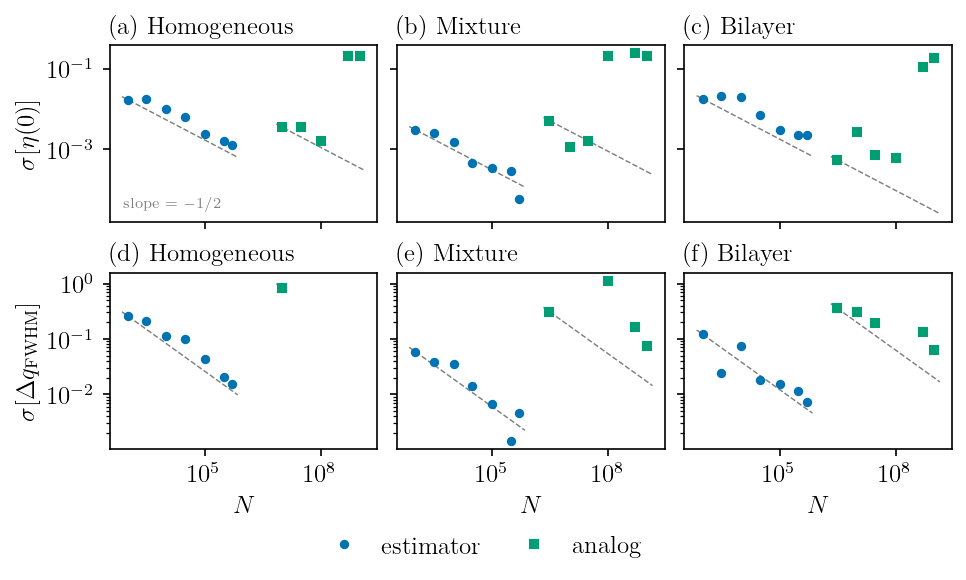

In [44]:
apply(width_frac=1.0)
fig, axes = plt.subplots(2, len(MEDIA), figsize=(TEXTWIDTH_IN, 0.60 * TEXTWIDTH_IN),
                         sharex=True, sharey="row", squeeze=False)
tags = iter("abcdef")

SCALARS = [("s_eta0", r"$\sigma[\eta(0)]$"),
           ("s_dq",   r"$\sigma[\Delta q_{\mathrm{FWHM}}]$")]

for i, (field, ylab) in enumerate(SCALARS):
    for j, m in enumerate(MEDIA):
        ax = axes[i, j]
        for mode in MODE_ORDER:
            st = MODE_STYLE[mode]
            ns = LADDER[(m, mode)]
            s  = np.array([POINTS[m][(mode, n)][field] for n in ns])
            ok = np.isfinite(s) & (s > 0)
            ax.plot(np.array(ns)[ok], s[ok], marker=st["marker"], ms=3.5,
                    ls="none", color=st["color"], label=mode)
            if ok.any():
                n0, s0 = np.array(ns)[ok][0], s[ok][0]
                nl = np.array([n0 * 0.7, np.array(ns)[ok][-1] * 1.4])
                ax.plot(nl, s0 * (nl / n0) ** -0.5, "--", c="gray", lw=0.7, zorder=0)
        ax.set(xscale="log", yscale="log")
        ax.set_title(rf"({next(tags)}) {m}", loc="left")
        ax.grid(False)
        if i == 1:
            ax.set_xlabel(r"$N$")
    axes[i, 0].set_ylabel(ylab)

axes[0, 0].annotate(r"slope $=-1/2$", (0.05, 0.08), xycoords="axes fraction",
                    fontsize=7, color="gray")
leyenda_inferior(fig, axes[0, 0], ncol=2)
fig.savefig(FIGDIR / "conv_sigma_vs_N.pdf")
plt.show()

## 8. F5 — Costo

(a) Tiempo de pared del punto completo (suma de las $R$ réplicas) vs. $N$: debe
ser una recta de pendiente $+1$ en log-log; cualquier curvatura delata overhead
por corrida o saturación de memoria. (b) Rendimiento en fotones/s por modo y
medio — la penalización por fotón del estimador es directamente la razón entre
las barras, y se espera $\sim$ lineal en `N_THETA`.

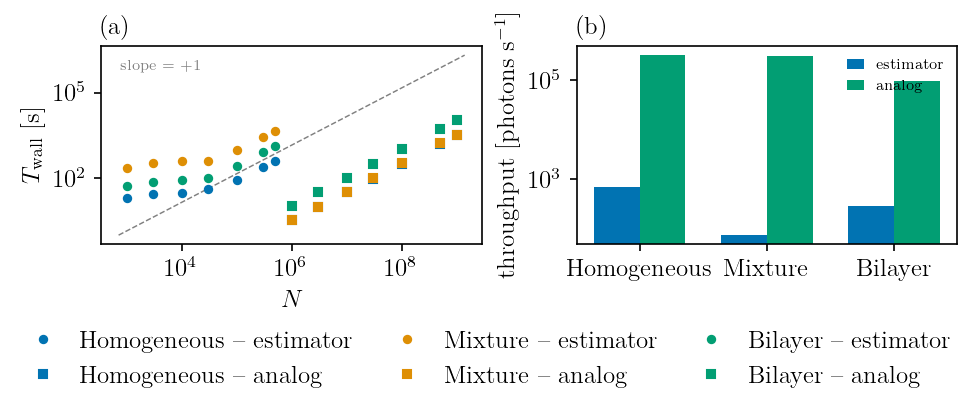

,medium,mode,slope,rate,T_total_h
0,Homogeneous,estimator,0.466,687.833,0.232
1,Homogeneous,analog,0.992,313273.992,1.452
2,Mixture,estimator,0.451,74.115,2.649
3,Mixture,analog,0.994,300343.631,1.517
4,Bilayer,estimator,0.507,289.956,0.747
5,Bilayer,analog,0.996,94580.806,4.819


In [45]:
apply(width_frac=1.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

rows = []
for m in MEDIA:
    for mode in MODE_ORDER:
        ns = np.array(LADDER[(m, mode)], float)
        T  = np.array([POINTS[m][(mode, int(n))]["T_wall"] for n in ns])
        st = MODE_STYLE[mode]
        a1.plot(ns, T, marker=st["marker"], ms=3.5, ls="none",
                mfc=MEDIA_COLOR[m], mec=MEDIA_COLOR[m], color=MEDIA_COLOR[m],
                label=f"{m} -- {mode}")
        rows.append(dict(medium=m, mode=mode,
                         slope=np.polyfit(np.log(ns), np.log(T), 1)[0],
                         rate=float(np.median(ns / T)),
                         T_total_h=float(T.sum() / 3600.0)))

nl = np.array([min(r for k in LADDER for r in LADDER[k]) * 0.7,
               max(r for k in LADDER for r in LADDER[k]) * 1.4])
ref = rows[0]
a1.plot(nl, nl / ref["rate"], "--", c="gray", lw=0.7, zorder=0)
a1.set(xscale="log", yscale="log", xlabel=r"$N$", ylabel=r"$T_{\mathrm{wall}}$ [s]")
a1.set_title("(a)", loc="left")
a1.annotate(r"slope $=+1$", (0.05, 0.88), xycoords="axes fraction",
            fontsize=7, color="gray")
a1.grid(False)

df_cost = pd.DataFrame(rows)

# (b) rendimiento por modo/medio
x = np.arange(len(MEDIA))
w = 0.36
for k, mode in enumerate(MODE_ORDER):
    rate_of = {(d["medium"], d["mode"]): d["rate"] for d in rows}
    r = [rate_of[(m, mode)] for m in MEDIA]
    a2.bar(x + (k - 0.5) * w, r, width=w, color=MODE_STYLE[mode]["color"],
           label=mode, edgecolor="none")
a2.set_yscale("log")
a2.set_xticks(x)
a2.set_xticklabels(MEDIA)
a2.set_ylabel(r"throughput [photons s$^{-1}$]")
a2.set_title("(b)", loc="left")
a2.legend(frameon=False, handlelength=1.2, fontsize=7)
a2.grid(False)

leyenda_inferior(fig, a1, ncol=3)
fig.savefig(FIGDIR / "conv_cost_vs_N.pdf")
plt.show()

df_cost.to_csv(FIGDIR / "conv_cost.csv", index=False)
df_cost.round(3)

## 9. F6 — Veredicto: figura de mérito

$\mathrm{FOM} = 1/(\sigma^2 T)$ con $\sigma = \sigma[\eta(0)]$ del punto
completo y $T$ el tiempo de pared del punto. Si $\sigma^2 \propto 1/N$ y
$T \propto N$, la FOM es **independiente de $N$**: la meseta es la propiedad
intrínseca del método y su cociente entre modos es la ganancia real.

(a) $\sigma[\eta(0)]$ vs. tiempo — comparación **a igual costo**, que es la
pregunta operativa. (b) FOM vs. $N$; la ganancia anotada es la mediana del
cociente de las mesetas.

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_45963/1503528710.py:11: RuntimeWarning: divide by zero encountered in divide
  fom = 1.0 / (s ** 2 * T)


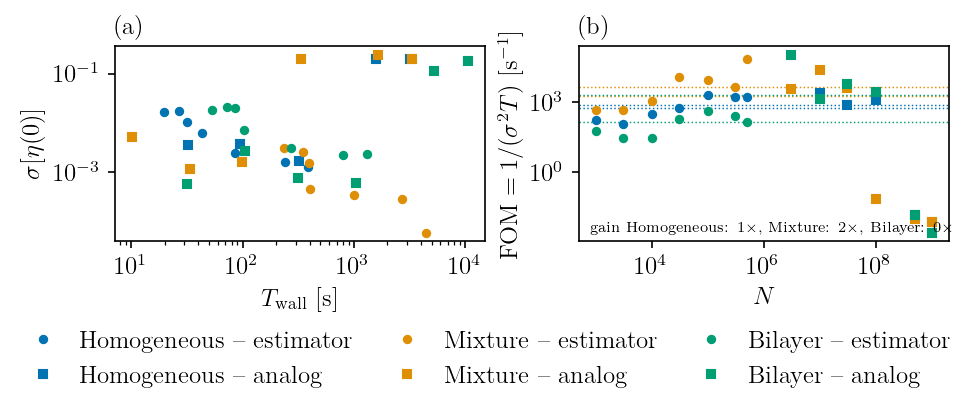

mode,analog,estimator,gain
medium,,,
Bilayer,1979.255,145.433,0.073
Homogeneous,769.158,574.302,0.747
Mixture,1841.699,4498.436,2.443


In [46]:
apply(width_frac=1.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

fom_rows = []
for m in MEDIA:
    for mode in MODE_ORDER:
        ns = np.array(LADDER[(m, mode)], float)
        T  = np.array([POINTS[m][(mode, int(n))]["T_wall"] for n in ns])
        s  = np.array([POINTS[m][(mode, int(n))]["s_eta0"] for n in ns])
        ok = np.isfinite(s) & (s > 0) & np.isfinite(T) & (T > 0)
        fom = 1.0 / (s ** 2 * T)

        st = MODE_STYLE[mode]
        a1.plot(T[ok], s[ok], marker=st["marker"], ms=3.5, ls="none",
                color=MEDIA_COLOR[m], label=f"{m} -- {mode}")
        a2.plot(ns[ok], fom[ok], marker=st["marker"], ms=3.5, ls="none",
                color=MEDIA_COLOR[m])

        for n_, t_, s_, f_ in zip(ns[ok], T[ok], s[ok], fom[ok]):
            fom_rows.append(dict(medium=m, mode=mode, N=int(n_),
                                 T_wall=t_, sigma_eta0=s_, FOM=f_))

df_fom = pd.DataFrame(fom_rows)

# meseta = mediana de la FOM sobre la escalera; ganancia = cociente por medio
plateau = df_fom.groupby(["medium", "mode"])["FOM"].median().unstack()
plateau["gain"] = plateau["estimator"] / plateau["analog"]

a1.set(xscale="log", yscale="log", xlabel=r"$T_{\mathrm{wall}}$ [s]",
       ylabel=r"$\sigma[\eta(0)]$")
a1.set_title("(a)", loc="left")
a1.grid(False)

for m in MEDIA:
    a2.axhline(plateau.loc[m, "estimator"], ls=":", lw=0.7,
               color=MEDIA_COLOR[m], zorder=0)
    a2.axhline(plateau.loc[m, "analog"], ls=":", lw=0.7,
               color=MEDIA_COLOR[m], zorder=0)
a2.set(xscale="log", yscale="log", xlabel=r"$N$",
       ylabel=r"$\mathrm{FOM} = 1/(\sigma^2 T)$ [s$^{-1}$]")
a2.set_title("(b)", loc="left")
a2.annotate("gain " + ", ".join(f"{m}: {plateau.loc[m, 'gain']:.0f}$\\times$"
                                for m in MEDIA),
            (0.03, 0.05), xycoords="axes fraction", fontsize=7, color="k")
a2.grid(False)

leyenda_inferior(fig, a1, ncol=3)
fig.savefig(FIGDIR / "conv_fom.pdf")
plt.show()

df_fom.to_csv(FIGDIR / "conv_fom.csv", index=False)
plateau.round(3)

## 10. Tabla resumen

Una fila por (medio, modo): el valor convergido de los dos escalares con su
intervalo, el costo total y la FOM. Es la tabla que se cita en el texto.

In [47]:
rows = []
for m in MEDIA:
    for mode in MODE_ORDER:
        n = NMAX[(m, mode)]
        d = POINTS[m][(mode, n)]
        rows.append({
            "medium":        m,
            "mode":          mode,
            "N_max":         n,
            "eta(0)":        d["eta0"],
            "CI_eta(0)":     T_CRIT * d["s_eta0"],
            "dq_FWHM":       d["dq"],
            "CI_dq":         T_CRIT * d["s_dq"],
            "T_wall [s]":    d["T_wall"],
            "cpu/wall":      d["T_cpu"] / d["T_wall"] if d["T_wall"] > 0 else np.nan,
            "photons/s":     n / d["T_wall"] if d["T_wall"] > 0 else np.nan,
            "hits":          d["hits"],
            "FOM":           1.0 / (d["s_eta0"] ** 2 * d["T_wall"]),
        })

df_sum = pd.DataFrame(rows)
df_sum.to_csv(FIGDIR / "conv_summary.csv", index=False)
df_sum.round(4)

,medium,mode,N_max,eta(0),CI_eta(0),dq_FWHM,CI_dq,T_wall [s],cpu/wall,photons/s,hits,FOM
0,Homogeneous,estimator,500000,1.9783,0.0036,1.4127,0.0419,389.1110,43.9835,1284.9805,53662910.0,1555.4554
1,Homogeneous,analog,1000000000,1.9897,0.5533,0.9763,NaN,3178.0798,45.8881,314655.4046,4063376.0,0.0079
2,Mixture,estimator,500000,1.9851,0.0002,1.0746,0.0128,4410.9699,43.8257,113.3538,53717783.0,67202.8269
3,Mixture,analog,1000000000,1.9950,0.5537,0.7920,0.2074,3320.9817,45.8845,301115.7782,15369515.0,0.0076
4,Bilayer,estimator,500000,1.9664,0.0064,0.3871,0.0202,1304.4912,44.2926,383.2912,176355409.0,145.4329
5,Bilayer,analog,1000000000,1.9711,0.5138,0.3382,0.1782,10549.1653,45.8861,94794.2301,8397492.0,0.0028


In [48]:
# --- costo para alcanzar una precision objetivo -----------------------------
# Con FOM constante, T(sigma_obj) = 1 / (FOM * sigma_obj^2). Traduce la meseta
# a la unica cifra que le importa a quien planea una campana.
SIGMA_TARGET = 1e-3      # incertidumbre objetivo en eta(0)

tab = plateau[["estimator", "analog"]].copy()
for mode in MODE_ORDER:
    tab[f"T_{mode} [h]"] = 1.0 / (tab[mode] * SIGMA_TARGET ** 2) / 3600.0
tab["speedup"] = tab["T_analog [h]"] / tab["T_estimator [h]"]

print(f"tiempo para sigma[eta(0)] = {SIGMA_TARGET:g}")
tab[[f"T_{m} [h]" for m in MODE_ORDER] + ["speedup"]].round(3)

tiempo para sigma[eta(0)] = 0.001


mode,T_estimator [h],T_analog [h],speedup
medium,,,
Bilayer,1.910,0.140,0.073
Homogeneous,0.484,0.361,0.747
Mixture,0.062,0.151,2.443


## 11. Cómo se lee esta sección

- **F1** es el permiso para todo lo demás: si $\Delta\eta$ no es compatible con
  cero dentro del cono, el estimador tiene un sesgo y la comparación de costos
  es irrelevante. El caso de mezcla es el más exigente porque la normalización
  `I_norm` cacheada por `(medium, k)` se invalida vértice a vértice.
- **F2/F3** dicen dónde recortar la escalera en campañas futuras: el punto
  donde $D_{\rm rms}$ toca el piso sistemático es el primer $N$ que ya no
  compra nada.
- **F4** valida el $N^{-1/2}$; una serie que se aplana antes es señal de piso
  sistemático (baseline, semilla, o el pedestal de single-scatter).
- **F5** separa las dos penalizaciones: el estimador paga por fotón
  (proporcional a `N_THETA`), el análogo paga en número de fotones.
- **F6** es la cifra que va al texto. La meseta de la FOM y el tiempo para una
  precisión objetivo son lo que decide qué modo usar en producción.

Puntos a verificar antes de citar números en la tesis: que las tres campañas
tengan el mismo `N_THETA` (si no, las FOM no son comparables), que
`n_threads` sea el mismo en todas las corridas, y que `cpu/wall` de la tabla
resumen sea consistente con los 46 hilos.